## 環境設置

跟前面兩個 Case 一樣,自動偵測並安裝需要的套件,讓這份 notebook 在任何
環境都能獨立跑起來。

In [1]:
try:
    import openseespy.opensees as ops  # noqa: F401
    print("openseespy 已存在,略過安裝")
except ImportError:
    import sys
    print("偵測不到 openseespy,開始安裝...")
    !{sys.executable} -m pip install -q openseespy
    import openseespy.opensees as ops  # noqa: F401
    print("安裝完成")

try:
    import numpy as np  # noqa: F401
except ImportError:
    import sys
    !{sys.executable} -m pip install -q numpy

openseespy 已存在,略過安裝


# Case-03:一跨二層構架驗證

依 [ROADMAP.md](../ROADMAP.md) 規劃,這是第一次出現「樓層」的概念——
兩個自由度(1F、屋頂),樓層地震力分配,特徵值分析要處理真正的矩陣
(不再是 Case-01 那種單自由度的純量)。

**跟 Case-02 的關鍵連結**:Case-02 驗證梁勁度趨近無限大時,單層構架
的側向勁度會收斂到 `2×12EIc/h³`(兩柱並聯、柱頂完全不轉動的極限情況)。
這裡直接**沿用那個驗證過的極限公式**當作每一層的樓層勁度——不是重新
假設,是把上一個 Case 已經證明對的結論直接接過來用。這就是「剪力構架
假設」(shear building):假設樓板夠剛,柱頂柱底轉角視為零,每層退化
成一根等效彈簧。

## 第 1 課:問題定義

| 參數 | 值 |
|---|---|
| 層高 h1=h2 | 3.5 m(呼應桃園案例的層高) |
| 跨度 L | 6.0 m |
| 柱斷面 | 與 Case-02 相同(Ic=0.0010 m⁴, E=25,000,000 kN/m²) |
| 1F 質量 m1 | 50 公噸(呼應 Case-01 用過的質量) |
| 屋頂質量 m2 | 40 公噸(較輕,呼應真實建築屋頂通常靜載較低) |

> **單位提醒**:這裡質量刻意用「公噸」而非「公斤」——K 矩陣的單位是
> kN/m,要跟質量矩陣搭配算出正確的 rad/s,必須維持公噸+kN+m+s的
> 一致單位制(1 kN = 1公噸·m/s²),混用公斤會讓算出來的週期差1000倍
> 還不容易發現哪裡錯,這是實際算錯過一次才確認的細節。

In [2]:
import numpy as np

h1, h2 = 3.5, 3.5
L = 6.0
E = 25_000_000.0
Ic = 0.0010
m1, m2 = 50.0, 40.0   # 公噸

print(f"h1=h2={h1} m, L={L} m")
print(f"E={E:.3e} kN/m^2, Ic={Ic} m^4")
print(f"m1={m1} 噸(1F), m2={m2} 噸(屋頂)")

h1=h2=3.5 m, L=6.0 m
E=2.500e+07 kN/m^2, Ic=0.001 m^4
m1=50.0 噸(1F), m2=40.0 噸(屋頂)


## 第 2 課:剪力構架假設與 K 矩陣手算

單柱剪力剛度(固定-滑動邊界,對應 Case-02 驗證過的梁無限剛極限):

$$k_{col} = \frac{12EI_c}{h^3}$$

每層樓層剛度 = 兩柱並聯:

$$k_1 = k_2 = 2k_{col}$$

兩自由度系統的勁度矩陣與質量矩陣:

$$K = \begin{bmatrix} k_1+k_2 & -k_2 \\ -k_2 & k_2 \end{bmatrix}, \qquad
M = \begin{bmatrix} m_1 & 0 \\ 0 & m_2 \end{bmatrix}$$

In [3]:
k_col = 12*E*Ic/h1**3
k1 = k2 = 2*k_col

print(f"k_col(單柱) = {k_col:.4f} kN/m")
print(f"k1=k2(樓層剛度) = {k1:.4f} kN/m")

# 對照 Case-02 驗證過的極限值(梁->無限剛), 應完全相等
K_limit_case02 = 13994.1691
rel_diff = abs(k1 - K_limit_case02) / K_limit_case02
print(f"對照Case-02驗證過的極限值 = {K_limit_case02} kN/m, 相對差異 = {rel_diff:.2e}")
assert rel_diff < 1e-4, "跟Case-02的極限值對不起來,參數是不是改了?"
print("[PASS] 與Case-02的驗證結果一致")

K_hand = np.array([[k1+k2, -k2], [-k2, k2]])
M_hand = np.array([[m1, 0.0], [0.0, m2]])
print(f"\nK矩陣 =\n{K_hand}")
print(f"M矩陣 =\n{M_hand}")

k_col(單柱) = 6997.0845 kN/m
k1=k2(樓層剛度) = 13994.1691 kN/m
對照Case-02驗證過的極限值 = 13994.1691 kN/m, 相對差異 = 2.71e-10
[PASS] 與Case-02的驗證結果一致

K矩陣 =
[[ 27988.33819242 -13994.16909621]
 [-13994.16909621  13994.16909621]]
M矩陣 =
[[50.  0.]
 [ 0. 40.]]


## 第 3 課:特徵值分析(手算)

廣義特徵值問題 $K\phi = \omega^2 M\phi$,用 `numpy` 直接解(這是精確的
線性代數解,不是近似——用程式解跟用紙筆解 2x2 特徵值問題,答案完全
一樣,只是省去手動展開特徵方程式的繁瑣代數)。

In [4]:
eigvals_hand, eigvecs_hand = np.linalg.eig(np.linalg.inv(M_hand) @ K_hand)
idx = np.argsort(eigvals_hand)
eigvals_hand = eigvals_hand[idx]
eigvecs_hand = eigvecs_hand[:, idx]

omegas_hand = np.sqrt(eigvals_hand)
periods_hand = 2*np.pi/omegas_hand

phi_hand = eigvecs_hand.copy()
for i in range(2):
    phi_hand[:, i] = phi_hand[:, i]/phi_hand[-1, i]   # 頂樓正規化為1

print(f"手算週期: T1={periods_hand[0]:.6f} s (第一模態), T2={periods_hand[1]:.6f} s (第二模態)")
print(f"振型(頂樓正規化為1):\n{phi_hand}")

手算週期: T1=0.562528 s (第一模態), T2=0.224276 s (第二模態)
振型(頂樓正規化為1):
[[ 0.64339811 -1.24339811]
 [ 1.          1.        ]]


## 第 4 課:OpenSeesPy 建模

**關鍵技巧**:不需要真的建梁元素——用 `ops.fix(node, 0,1,1)` 把每個
樓層節點的軸向(Uy)與轉角(Rz)都拘束住,只留水平自由度(Ux),
就是「剪力構架假設」最直接的實作方式;再用 `ops.equalDOF` 把同一
樓層兩個節點的水平自由度綁在一起,代表剛性樓板。這樣算出來的每根柱
行為,精確等於固定-滑動邊界(k=12EI/h³),不是用很大的數字去逼近,
是真正精確的邊界條件。

In [5]:
ops.wipe()
ops.model('basic', '-ndm', 2, '-ndf', 3)

ops.node(1, 0.0, 0.0);        ops.node(2, L, 0.0)          # 基礎
ops.node(3, 0.0, h1);         ops.node(4, L, h1)           # 1F
ops.node(5, 0.0, h1+h2);      ops.node(6, L, h1+h2)        # 屋頂

ops.fix(1, 1, 1, 1)
ops.fix(2, 1, 1, 1)
for n in [3, 4, 5, 6]:
    ops.fix(n, 0, 1, 1)   # Ux自由, Uy與Rz都拘束 -> 剪力構架假設

ops.equalDOF(3, 4, 1)   # 1F樓板剛性
ops.equalDOF(5, 6, 1)   # 屋頂樓板剛性

A_big = 1.0e6
ops.geomTransf('Linear', 1)
ops.element('elasticBeamColumn', 1, 1, 3, A_big, E, Ic, 1)  # 1F左柱
ops.element('elasticBeamColumn', 2, 2, 4, A_big, E, Ic, 1)  # 1F右柱
ops.element('elasticBeamColumn', 3, 3, 5, A_big, E, Ic, 1)  # 2F左柱
ops.element('elasticBeamColumn', 4, 4, 6, A_big, E, Ic, 1)  # 2F右柱

ops.mass(3, m1, 0.0, 0.0)
ops.mass(5, m2, 0.0, 0.0)

print("模型建立完成: 6節點, 4根柱元素, 2組equalDOF(剛性樓板)")

模型建立完成: 6節點, 4根柱元素, 2組equalDOF(剛性樓板)


## 第 5 課:特徵值分析驗證

單自由度系統(Case-01)用 `'-fullGenLapack'` 是因為 ARPACK 對太小的
系統會報錯;這裡是 2 個自由度,一樣屬於小系統,沿用同一個選項。

In [6]:
eigVals_ops = ops.eigen('-fullGenLapack', 2)
omegas_ops = np.sqrt(eigVals_ops)
periods_ops = 2*np.pi/omegas_ops

print(f"手算週期:      T1={periods_hand[0]:.8f} s, T2={periods_hand[1]:.8f} s")
print(f"OpenSeesPy週期: T1={periods_ops[0]:.8f} s, T2={periods_ops[1]:.8f} s")

rel_err_T1 = abs(periods_ops[0]-periods_hand[0])/periods_hand[0]
rel_err_T2 = abs(periods_ops[1]-periods_hand[1])/periods_hand[1]
print(f"相對誤差: T1={rel_err_T1:.3e}, T2={rel_err_T2:.3e}")

assert rel_err_T1 < 1e-6 and rel_err_T2 < 1e-6, "週期不吻合,建模有問題!"
print("[PASS] 兩個模態週期皆與手算吻合")

手算週期:      T1=0.56252844 s, T2=0.22427617 s
OpenSeesPy週期: T1=0.56252844 s, T2=0.22427617 s
相對誤差: T1=0.000e+00, T2=1.238e-16
[PASS] 兩個模態週期皆與手算吻合


WARNING - the 'fullGenLapack' eigen solver is VERY SLOW. Consider using the default eigen solver.

## 第 6 課:靜力測試驗證

施加任意樓層力(這裡的數字純粹用來測試模型,不代表真實地震力——
真實地震力分配要到 Case-04 桃園案例才套用規範算出來的 F1、F2)。

In [7]:
F1, F2 = 30.0, 50.0  # kN, 測試用樓層力(非真實地震力)
u_hand = np.linalg.solve(K_hand, np.array([F1, F2]))

ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
ops.load(3, F1, 0.0, 0.0)
ops.load(5, F2, 0.0, 0.0)

ops.system('BandGeneral')
ops.numberer('RCM')
ops.constraints('Transformation')   # equalDOF需要Transformation或Lagrange, 不能用Plain
ops.test('NormDispIncr', 1e-10, 20)
ops.algorithm('Newton')
ops.integrator('LoadControl', 1.0)
ops.analysis('Static')
ops.analyze(1)

u1_ops = ops.nodeDisp(3, 1)
u2_ops = ops.nodeDisp(5, 1)

print(f"手算位移:      u1(1F)={u_hand[0]:.8f} m, u2(屋頂)={u_hand[1]:.8f} m")
print(f"OpenSeesPy位移: u1(1F)={u1_ops:.8f} m, u2(屋頂)={u2_ops:.8f} m")

rel_err_u1 = abs(u1_ops-u_hand[0])/u_hand[0]
rel_err_u2 = abs(u2_ops-u_hand[1])/u_hand[1]
print(f"相對誤差: u1={rel_err_u1:.3e}, u2={rel_err_u2:.3e}")

assert rel_err_u1 < 1e-6 and rel_err_u2 < 1e-6, "位移不吻合,建模有問題!"
print("[PASS] 樓層位移與手算吻合")

手算位移:      u1(1F)=0.00571667 m, u2(屋頂)=0.00928958 m
OpenSeesPy位移: u1(1F)=0.00571667 m, u2(屋頂)=0.00928958 m
相對誤差: u1=3.035e-16, u2=1.867e-16
[PASS] 樓層位移與手算吻合


## 第 7 課:結構視覺化

左圖是構架幾何、支承與樓層力方向;右圖是兩個模態的振型形狀
(放大顯示,方便比較第一模態跟第二模態的變形樣式差異——第一模態
兩層樓同向擺動,第二模態上下層反向擺動,這是多自由度系統的典型
特徵)。

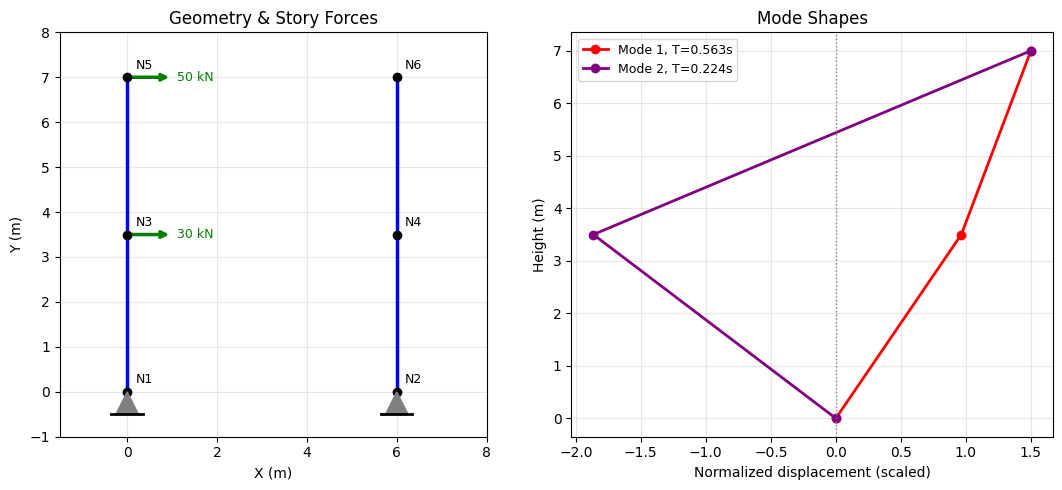

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

nodes_xy = {1:(0,0), 2:(L,0), 3:(0,h1), 4:(L,h1), 5:(0,h1+h2), 6:(L,h1+h2)}
elems_conn = [(1,1,3),(2,2,4),(3,3,5),(4,4,6)]
fixed_nodes = [1,2]
loaded_nodes = {3:(F1,0.0), 5:(F2,0.0)}

fig, axes = plt.subplots(1, 2, figsize=(11,5))

# ---- 左圖: 幾何與載重 ----
ax = axes[0]
for eid,ni,nj in elems_conn:
    xi,yi = nodes_xy[ni]; xj,yj = nodes_xy[nj]
    ax.plot([xi,xj],[yi,yj],'b-',lw=2.5,zorder=2)
for n,(x,y) in nodes_xy.items():
    ax.plot(x,y,'ko',ms=6,zorder=4)
    ax.annotate(f'N{n}',(x,y),textcoords="offset points",xytext=(6,6),fontsize=9)
for n in fixed_nodes:
    x,y = nodes_xy[n]
    tri = plt.Polygon([(x-0.25,y-0.5),(x+0.25,y-0.5),(x,y)],closed=True,color='gray',zorder=5)
    ax.add_patch(tri)
    ax.plot([x-0.35,x+0.35],[y-0.5,y-0.5],'k-',lw=2,zorder=5)
for n,(fx,fy) in loaded_nodes.items():
    x,y = nodes_xy[n]
    ax.annotate('', xy=(x+1.0,y), xytext=(x,y), arrowprops=dict(arrowstyle='->',color='green',lw=2.5))
    ax.text(x+1.1,y,f'{fx:.0f} kN',color='green',fontsize=9,va='center')
ax.set_xlim(-1.5,L+2); ax.set_ylim(-1.0,h1+h2+1.0)
ax.set_aspect('equal'); ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('Geometry & Story Forces')
ax.grid(True, alpha=0.3)

# ---- 右圖: 模態振型 ----
ax = axes[1]
mode_scale = 1.5
colors = ['red', 'purple']
for i in range(2):
    ux = [0, phi_hand[0,i], phi_hand[1,i]]  # 基礎, 1F, 屋頂 (水平位移, 已正規化)
    yy = [0, h1, h1+h2]
    ax.plot([v*mode_scale for v in ux], yy, 'o-', color=colors[i], lw=2,
            label=f'Mode {i+1}, T={periods_hand[i]:.3f}s')
ax.axvline(0, color='gray', lw=1, ls=':')
ax.set_xlabel('Normalized displacement (scaled)'); ax.set_ylabel('Height (m)')
ax.set_title('Mode Shapes')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 總結表

In [9]:
print("="*50)
print("Case-03 一跨二層構架驗證結果總結")
print("="*50)
print(f"{'k1=k2(樓層剛度)':<24}{k1:.4f} kN/m")
print(f"{'手算T1':<24}{periods_hand[0]:.6f} s")
print(f"{'OpenSeesPy T1':<24}{periods_ops[0]:.6f} s")
print(f"{'T1相對誤差':<24}{rel_err_T1:.2e}")
print(f"{'手算T2':<24}{periods_hand[1]:.6f} s")
print(f"{'OpenSeesPy T2':<24}{periods_ops[1]:.6f} s")
print(f"{'T2相對誤差':<24}{rel_err_T2:.2e}")
print(f"{'手算u1':<24}{u_hand[0]:.8f} m")
print(f"{'OpenSeesPy u1':<24}{u1_ops:.8f} m")
print(f"{'u1相對誤差':<24}{rel_err_u1:.2e}")
print()
print("Case-03 [PASS] -- 可以進到 Case-03.5(試設斷面)")

Case-03 一跨二層構架驗證結果總結
k1=k2(樓層剛度)             13994.1691 kN/m
手算T1                    0.562528 s
OpenSeesPy T1           0.562528 s
T1相對誤差                  0.00e+00
手算T2                    0.224276 s
OpenSeesPy T2           0.224276 s
T2相對誤差                  1.24e-16
手算u1                    0.00571667 m
OpenSeesPy u1           0.00571667 m
u1相對誤差                  3.03e-16

Case-03 [PASS] -- 可以進到 Case-03.5(試設斷面)
